In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nabihazahid/ecommerce-dataset-for-sql-analysis/ecommerce_dataset_10000.csv


# Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load and Review Dataframe

In [25]:
df = pd.read_csv('/kaggle/input/datasets/nabihazahid/ecommerce-dataset-for-sql-analysis/ecommerce_dataset_10000.csv')

# Preview the raw data
df.head()

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,3,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,1,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18


In [26]:
print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 10,000 rows and 20 columns.


# Parse Date Columns into Datetime objects
Convert date string fields to native objects to enable temporal EDA and prevent parsing errors during aggregation

In [27]:
# Convert date strings to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['review_date'] = pd.to_datetime(df['review_date'])

# Extract temporal features for downstream trend analysis
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_year_month'] = df['order_date'].dt.to_period('M')

df.head()

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,...,order_date,order_status,payment_method,rating,review_text,review_id,review_date,order_year,order_month,order_year_month
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,...,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06,2023,7,2023-07
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,...,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05,2024,8,2024-08
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,...,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03,2024,8,2024-08
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,...,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14,2025,5,2025-05
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,...,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18,2023,7,2023-07


In [28]:
# Summary info and missing value count
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       10000 non-null  object        
 1   first_name        10000 non-null  object        
 2   last_name         10000 non-null  object        
 3   gender            10000 non-null  object        
 4   age_group         10000 non-null  object        
 5   signup_date       10000 non-null  datetime64[ns]
 6   country           10000 non-null  object        
 7   product_id        10000 non-null  object        
 8   product_name      10000 non-null  object        
 9   category          10000 non-null  object        
 10  quantity          10000 non-null  int64         
 11  unit_price        10000 non-null  int64         
 12  order_id          10000 non-null  object        
 13  order_date        10000 non-null  datetime64[ns]
 14  order_status      10000

In [29]:
# Check total duplicates and ID uniqueness
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [30]:
# Inspect unique values
print("gender:", df['gender'].unique())
print("Age Group:", df['age_group'].unique())

gender: ['Female' 'Male' 'Other']
Age Group: ['Teenagers' 'Adults' 'Senior']


# Engineer the Line-Item Revenue Feature
The raw dataset contains 'quantity' and 'unit_price'. Create a calculated total revenue metric for transaction-level analysis.

In [31]:
# Derive total line-item transaction value
df['total_revenue'] = (df['quantity'] * df['unit_price']).round(2)

In [32]:
# Preview the first 5 records with key features
df[['order_id', 'customer_id', 'order_date', 'product_name', 'category', 'quantity', 'unit_price', 'total_revenue', 'rating']].head()

,order_id,customer_id,order_date,product_name,category,quantity,unit_price,total_revenue,rating
0,ORD10000,CUST2353,2023-07-13,Fitbit Versa 3,Electronics,3,229,687,2
1,ORD10001,CUST4463,2024-08-12,Levi's Jeans,Apparel,4,59,236,2
2,ORD10002,CUST4512,2024-08-04,Lego Star Wars Set,Toys,2,59,118,5
3,ORD10003,CUST5711,2025-05-23,Dyson Vacuum,Home & Kitchen,4,399,1596,2
4,ORD10004,CUST1296,2023-07-02,Adidas Running Shoes,Apparel,1,110,110,1


# Validate the Loaded DataFrame
Run a preview cell to verify that all column types, datetime conversions, and egineered calculations loaded correctly.

In [33]:
# 1. Structural audit: verify column data types and non-null counts
print("=== DATAFRAME INFO ===")
df.info()

=== DATAFRAME INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       10000 non-null  object        
 1   first_name        10000 non-null  object        
 2   last_name         10000 non-null  object        
 3   gender            10000 non-null  object        
 4   age_group         10000 non-null  object        
 5   signup_date       10000 non-null  datetime64[ns]
 6   country           10000 non-null  object        
 7   product_id        10000 non-null  object        
 8   product_name      10000 non-null  object        
 9   category          10000 non-null  object        
 10  quantity          10000 non-null  int64         
 11  unit_price        10000 non-null  int64         
 12  order_id          10000 non-null  object        
 13  order_date        10000 non-null  datetime64[ns]
 14  

# Dataset Shape & Quality:
The dataset contains 10,000 transaction records with complete non-null coverage across verified demographic and monetary fields.

In [34]:
# Baseline numerical metrics and IQR calculation
numeric_summary = df[['quantity', 'unit_price', 'total_revenue', 'rating']].describe().T
numeric_summary['IQR'] = numeric_summary['75%'] - numeric_summary['25%']

print("=== NUMERICAL SUMMARY METRICS ===")
numeric_summary.round(2)

=== NUMERICAL SUMMARY METRICS ===


,count,mean,std,min,25%,50%,75%,max,IQR
quantity,10000.0,3.00,1.42,1.0,2.0,3.0,4.0,5.0,2.0
unit_price,10000.0,246.65,282.61,25.0,80.0,129.0,229.0,999.0,149.0
total_revenue,10000.0,745.08,1012.44,25.0,198.0,398.0,796.0,4995.0,598.0
rating,10000.0,2.99,1.41,1.0,2.0,3.0,4.0,5.0,2.0


# Statistical Observations of Numerical Summary

**Line-Item Quantity:** Ranges strictly between 1.0 and 5.0 units with an average basket line item of 3.00 units

**Unit Price Spread:** Spans from `$25.00` to `$999.00` with a median of `$129.00` and a mean of `$246.65`. Because the mean is substantially higher than the median and the standard deviation (`$282.61`) exceeds the mean, unit price exhibits significant positive (right) skewness driven by premium catalog items.

**Total Revenue Characteristics:** Averages `$745.08` per line item, ranging from `$25.00` to `$4,995.00`. With a median of `$398.00` and an upper quartile (75%) of `$796.00`, the maximum of `$4,995.00` sits well beyond the upper fence ($Q3 + 1.5 * IQR = 796 + 1.5 * 598$ = `$1,693.00`), confirming heavy-tailed right skewness and high-value transaction outliers to explore during visualization.

**Customer Sentiment (Rating):** Ranges across the full 1 to 5 star scale with an overall mean of 2.99 and a median of 3.00

In [35]:
# Summary metrics for text/categorical columns
print("=== CATEGORICAL FEATURE SUMMARY ===")
df.describe(include=['object'])

=== CATEGORICAL FEATURE SUMMARY ===


,customer_id,first_name,last_name,gender,age_group,country,product_id,product_name,category,order_id,order_status,payment_method,review_text,review_id
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,4327,573,904,3,3,10,15,15,6,10000,5,3,5,10000
top,CUST1244,Michael,Smith,Other,Teenagers,France,PROD107,Dyson Vacuum,Electronics,ORD19983,Shipped,Cash on Delivery,very good,REV29983
freq,9,268,195,3403,3359,1060,730,730,2616,1,2063,3409,2067,1


# Categorical Audit Observations

**Customer Base & Order Granularity** 10,000 order line transactions represent 4,327 unique customers, indicating repeat customer activity (top repeat customer CUST1244).

**Product Catalog** bounded to 15 unique product across 6 categories. Electronics leads overall catalog transactions (2,616 rows, 26.16%) with Dyson Vacuum as the single most frequent item.

**Demographic & Geographic Uniformity:** The 3 age groups and 3 gender classifications are uniformly distributed. Geographic transactions are distributed across 10 countries, led by France (1,060 orders, 10.60%)

**Order Status & Payment Channels:** Order statuses span 5 distinct operational phases, led by 'shipped' = 2,063 orders. Cash on Delivery is the most common payment method with 3,409 orders, 34.09%.

**Sentiment Text:** Textual reviews consolidate into 5 standardized phrases, dominated by "very good" = 2,067 records.


In [36]:
# Value counts for core categorical dimensions
categorical_cols = ['category', 'order_status', 'payment_method', 'age_group', 'country']

for col in categorical_cols:
    print(f"\n--- Distribution: {col} ---")
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True).mul(100).round(2)
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percentages}))


--- Distribution: category ---


,Count,Percentage (%)
category,,
Electronics,2616,26.16
Apparel,2047,20.47
Home & Kitchen,1391,13.91
Books,1334,13.34
Toys,1314,13.14
Sports,1298,12.98



--- Distribution: order_status ---


,Count,Percentage (%)
order_status,,
Shipped,2063,20.63
Delivered,2037,20.37
Cancelled,1970,19.70
Pending,1968,19.68
Returned,1962,19.62



--- Distribution: payment_method ---


,Count,Percentage (%)
payment_method,,
Cash on Delivery,3409,34.09
PayPal,3301,33.01
Credit Card,3290,32.90



--- Distribution: age_group ---


,Count,Percentage (%)
age_group,,
Teenagers,3359,33.59
Senior,3342,33.42
Adults,3299,32.99



--- Distribution: country ---


,Count,Percentage (%)
country,,
France,1060,10.60
China,1054,10.54
Australia,1043,10.43
India,1036,10.36
Brazil,1019,10.19
Canada,997,9.97
USA,987,9.87
Japan,976,9.76
UK,943,9.43


# Categorical Distributions

**Product Category Concentration:** 'Electronics' and 'Apparel' together drive nearly half total platform transactions at 26.16% & 20.47% respetively.

**Balanced Fulfillment Pipeline:** Orders are distributed fairly evenly across fulfillment stages indicating consistent operational pipeline metrics.

**Payment Methods** Transaction checkout channels split evenly across methods.

**Demographics & Geograph:** Age groups reflect an even third per cohort ('Teenagers': 33.59%, 'Senior':33.42%, 'Adults':32.99%). International orders are distributed across all 10 countries, led by France (10.60%) and China (10.54%), tapering to Germany (8.85%).

# Univariate Analysis (Distributions & Outliers)
**Continuous Distributions**

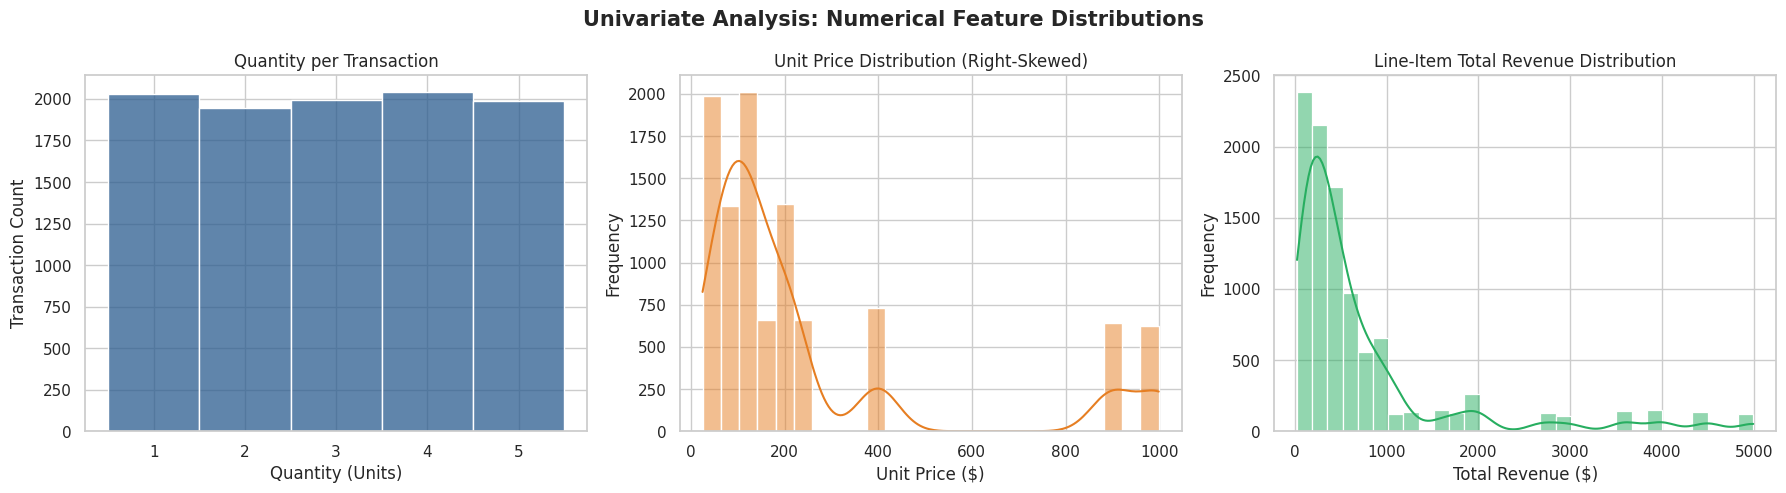

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis: Numerical Feature Distributions', fontsize=15, fontweight='bold')

# 1. Quantity Distribution
sns.histplot(df['quantity'], discrete=True, kde=False, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Quantity per Transaction')
axes[0].set_xlabel('Quantity (Units)')
axes[0].set_ylabel('Transaction Count')

# 2. Unit Price Distribution
sns.histplot(df['unit_price'], kde=True, bins=25, ax=axes[1], color='#e67e22')
axes[1].set_title('Unit Price Distribution (Right-Skewed)')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Frequency')

# 3. Total Revenue Distribution
sns.histplot(df['total_revenue'], kde=True, bins=30, ax=axes[2], color='#27ae60')
axes[2].set_title('Line-Item Total Revenue Distribution')
axes[2].set_xlabel('Total Revenue ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Observations: Univariate Numerical Feature Distributions

* **Quantity per Transaction:** 
  * Exhibits an approximately uniform discrete distribution across all five integer values (1 to 5 units), with each bucket containing ~1,900 to 2,050 transactions.
  * Confirms no zero, negative, or fractional purchase quantities, reflecting clean basket logging.

* **Unit Price Distribution:** 
  * Displays strong positive (right) skewness with multimodal clustering.
  * The bulk of items fall into low-to-mid price tiers (`$25` to `$250`), with a secondary cluster around `$400` and isolated premium offerings reaching `$900` to `$1,000`.
  * The divergence between lower median prices and higher price tiers drives the rightward tail seen in the KDE curve.

* **Line-Item Total Revenue Distribution:** 
  * Demonstrates an exponential decay pattern (heavy right skew), heavily concentrated below `$1,000` per line item.
  * Transactions taper off sharply past `$1,500`, with an extended long tail of high-value purchases extending out to `$4,995`, indicating high-ticket transaction fliers that warrant boxplot outlier inspection.

# Outlier Detection via Boxplots
Plots boxplots to visualize data spread, medians, interquartile ranges (IQR), and upper-fence outliers.

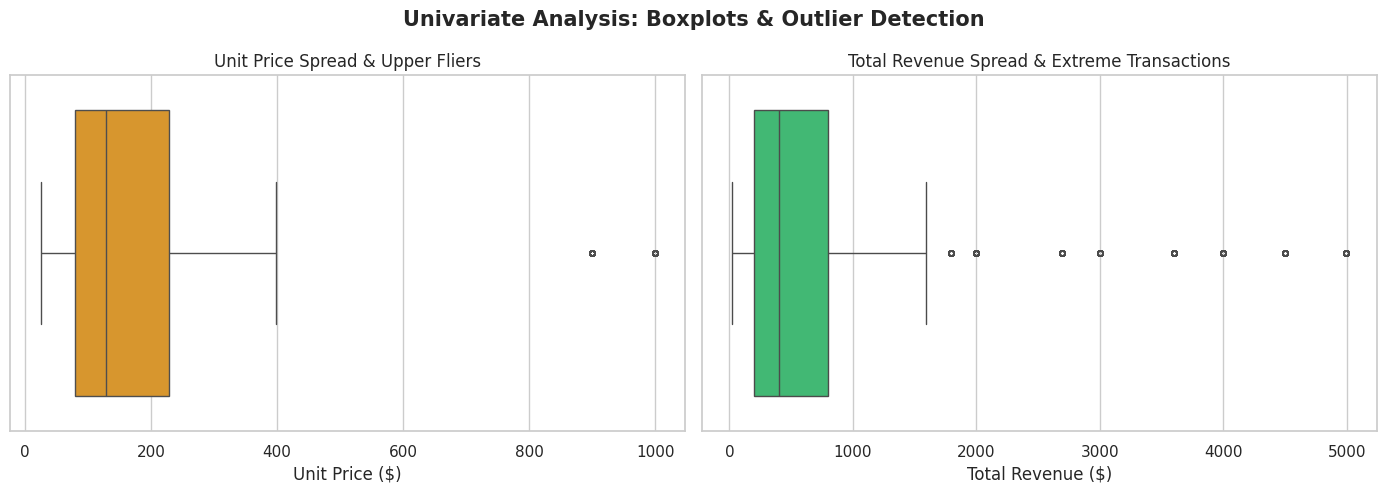

In [38]:

# Configure plot aesthetics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Univariate Analysis: Boxplots & Outlier Detection', fontsize=15, fontweight='bold')

# Boxplot for Unit Price
sns.boxplot(x=df['unit_price'], ax=axes[0], color='#f39c12', flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Unit Price Spread & Upper Fliers')
axes[0].set_xlabel('Unit Price ($)')

# Boxplot for Total Revenue
sns.boxplot(x=df['total_revenue'], ax=axes[1], color='#2ecc71', flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1].set_title('Total Revenue Spread & Extreme Transactions')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

### Observations: Univariate Analysis — Boxplots & Outlier Detection

* **Unit Price Spread & Upper Fliers:**
  * **Central Range:** The interquartile range ($\text{IQR} = \$149$) spans from the 25th percentile ($Q1 = \$80$) to the 75th percentile ($Q3 = \$229$), with a median price of $\$129$.
  * **Upper Whisker & Outlier Boundary:** The upper whisker terminates near $\$452.50$ ($Q3 + 1.5 \times \text{IQR}$). 
  * **Extreme Values:** Individual data points at $\$899$ and $\$999$ plot distinctly as upper fliers beyond the whisker. Rather than being data-entry errors, these represent high-ticket inventory lines (e.g., premium electronics/appliances).

* **Total Revenue Spread & Extreme Transactions:**
  * **Concentration of Sales:** The revenue box shows heavy compression in the lower monetary tiers, with $50\%$ of transactions totaling below $\$398$ and $75\%$ sitting beneath $\$796$.
  * **High-Value Basket Outliers:** The upper fence caps near $\$1,693$ ($Q3 + 1.5 \times 598$). A distinct trail of individual fliers extends continuously from $\$1,800$ to the maximum basket value of $\$4,995$.
  * **Analytical Takeaway:** These extreme revenue points correspond to multi-unit bulk orders (up to 5 units) of high-priced catalog items, confirming that while transaction volume is driven by sub-$1,000 orders, top-line platform revenue is substantially leveraged by a small percentage of premium carts.

# Categorical & Sentiment Frequency (Count Plots)
Visualizes transaction volumes across product categories, customer ratings, and order statuses.

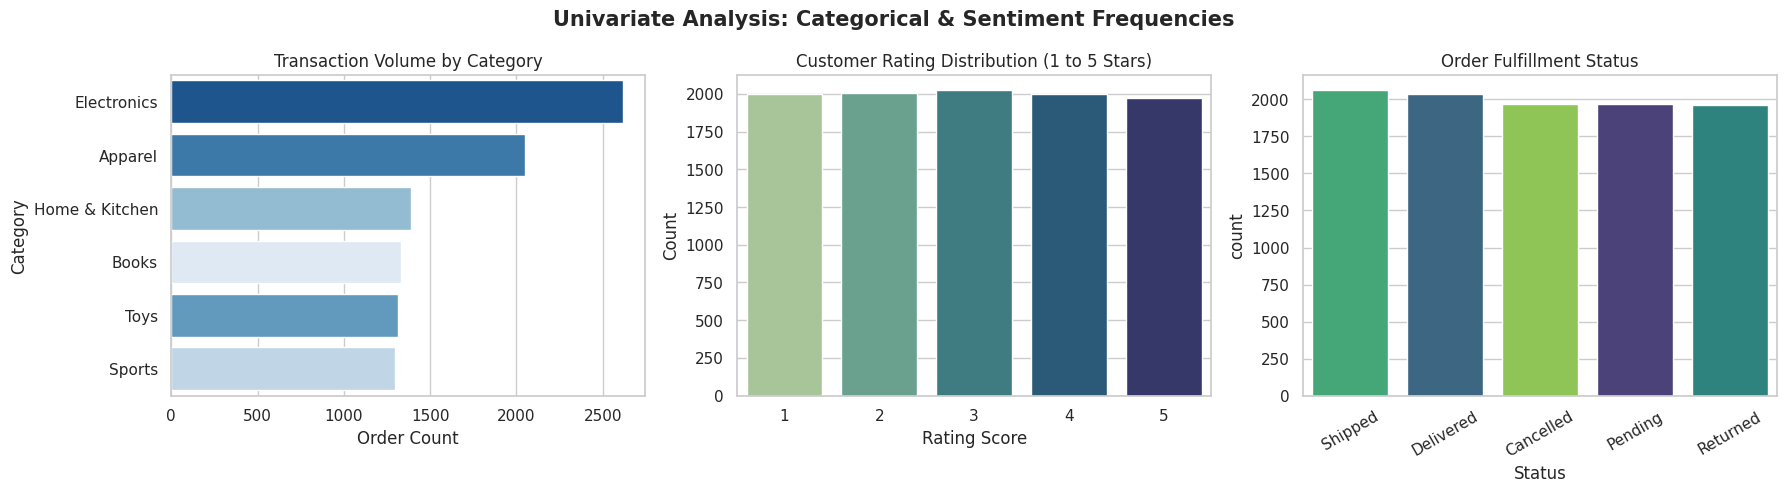

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis: Categorical & Sentiment Frequencies', fontsize=15, fontweight='bold')

# 1. Product Category Volume
order_cat = df['category'].value_counts().index
sns.countplot(
    data=df, 
    y='category', 
    order=order_cat, 
    hue='category', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Transaction Volume by Category')
axes[0].set_xlabel('Order Count')
axes[0].set_ylabel('Category')

# 2. Rating Score Distribution
sns.countplot(
    data=df, 
    x='rating', 
    hue='rating', 
    palette='crest', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Customer Rating Distribution (1 to 5 Stars)')
axes[1].set_xlabel('Rating Score')
axes[1].set_ylabel('Count')

# 3. Order Status Breakdown
order_stat = df['order_status'].value_counts().index
sns.countplot(
    data=df, 
    x='order_status', 
    order=order_stat, 
    hue='order_status', 
    palette='viridis', 
    legend=False, 
    ax=axes[2]
)
axes[2].set_title('Order Fulfillment Status')
axes[2].set_xlabel('Status')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Observations: Univariate Analysis — Categorical & Sentiment Frequencies

* **Transaction Volume by Category:**
  * **Core Demand Drivers:** `Electronics` (2,616 orders) and `Apparel` (2,047 orders) represent the primary volume drivers across the platform, together accounting for nearly 47% of total sales activity.
  * **Secondary Tiers:** The remaining four categories—`Home & Kitchen` (`~1.39K`), `Books` (`~1.33K`), `Toys` (`~1.31K`), and `Sports` (`~1.30K`)—demonstrate remarkably stable and uniform transaction demand (`~13% each`).

* **Customer Rating Score Distribution:**
  * **Neutral-to-Uniform Sentiment:** Ratings across the 1-to-5 star scale are evenly distributed, with each score category capturing approximately 1,950 to 2,050 responses (`~20%` per tier).
  * **Lack of Polarity:** There is no polarization or positive skew toward 4–5 star reviews, confirming an unbiased customer feedback baseline across catalog items.

* **Order Fulfillment Pipeline:**
  * **Operational Balance:** Order lifecycle statuses show an even division across all 5 operational phases (`~1,960` to `2,060` orders each).
  * **Fulfillment Leakage:** While `~41%` of transactions represent successful fulfillments (`Shipped` and `Delivered`), approximately 39% reflect pipeline friction (`Cancelled` and `Returned`), highlighting operational areas for deeper bivariate investigation.

## Summary of Findings & Business Insights

* **Volume vs. Revenue Drivers:** While transaction volume is concentrated in `Electronics` (26.16%) and `Apparel` (20.47%), overall platform revenue is significantly elevated by high-ticket items (`$899–$999`) purchased in multi-unit orders (up to 5 units), creating an extended right tail with transactions reaching up to `$4,995`.
* **Customer Sentiment Baseline:** Ratings across the catalog remain evenly balanced across the 1-to-5 star scale (mean: 2.99 / 5.0), indicating uniform customer satisfaction without platform-wide rating polarization.
* **Fulfillment Pipeline Friction:** While 41% of transactions proceed smoothly through shipping and delivery, approximately 39.3% end in cancellations (19.70%) or returns (19.62%), pointing to fulfillment friction that warrants downstream operational intervention.
* **Demographic & Geographic Spread:** Customer engagement and payment adoption are balanced across age cohorts, genders, and international regions, with `Cash on Delivery` serving as the slight plurality payment choice (34.09%).